In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn

RANDOMNESS_VALUE = 42
LEARN_RATE = 0.01
EPOCHS = 400

In [2]:
# Read the 08-seismic_activity_svm.csv file
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
# We have 3 columns, underground_wave_energy, vibration_axis_variation, seismic_event_detected
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


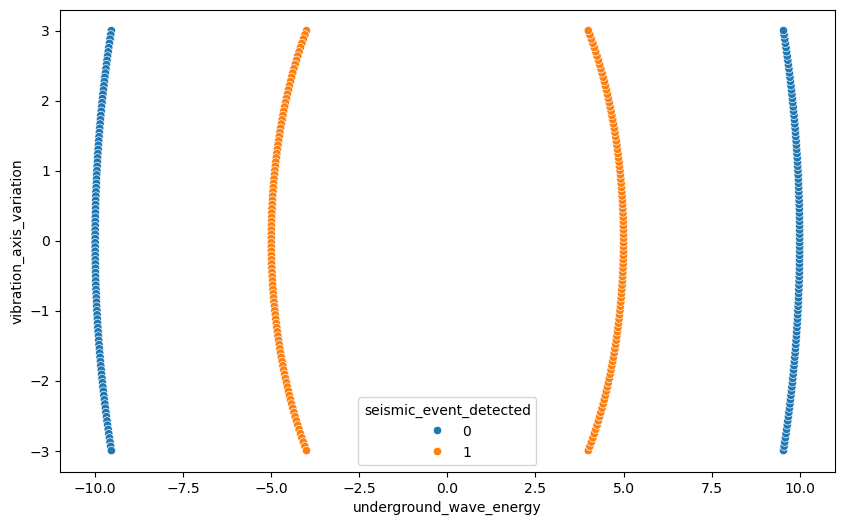

In [4]:
plt.figure(figsize=(10, 6))

df_underground_wave_energy = df["underground_wave_energy"]
df_vibration_axis_variation = df["vibration_axis_variation"]
df_seismic_event_detected = df["seismic_event_detected"]

sns.scatterplot(x=df_underground_wave_energy, y=df_vibration_axis_variation, hue=df_seismic_event_detected)
plt.show()


In [5]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOMNESS_VALUE)

In [7]:
print(f"length of X_train: {len(X_train)}, length of y_train: {len(y_train)}")
print(f"length of X_test: {len(X_test)}, length of y_test: {len(y_test)}")

length of X_train: 320, length of y_train: 320
length of X_test: 80, length of y_test: 80


In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [9]:
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: torch.Size([320, 2])
X_test.shape: torch.Size([80, 2])
y_train.shape: torch.Size([320, 1])
y_test.shape: torch.Size([80, 1])


In [10]:
class SeismicActivityModel(nn.Module):

    # We have 2 input, 2 hidden layers with 3 neurons each, and 1 output
    def __init__(self):
        super().__init__()
        self.first_layer = nn.Linear(in_features=2, out_features=3)
        self.second_layer = nn.Linear(in_features=3, out_features=3)
        self.third_layer = nn.Linear(in_features=3, out_features=1)

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.third_layer(
            self.relu(
                self.second_layer(
                    self.relu(
                        self.first_layer(x)
                    )
                )
            )
        )

In [11]:
model = SeismicActivityModel()
print(model)

SeismicActivityModel(
  (first_layer): Linear(in_features=2, out_features=3, bias=True)
  (second_layer): Linear(in_features=3, out_features=3, bias=True)
  (third_layer): Linear(in_features=3, out_features=1, bias=True)
  (relu): ReLU()
)


In [12]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARN_RATE)

In [13]:
def calculate_accuracy(test_dataframe, prediction_dataframe):
    return (torch.eq(test_dataframe, prediction_dataframe).sum().item() / len(test_dataframe)) * 100

In [14]:
y_logits = model(X_train)[:20]
y_pred_probs = torch.sigmoid(y_logits)
y_preds = torch.round(y_pred_probs)

In [15]:
calculate_accuracy(y_test[:20], y_preds)

45.0

In [16]:
torch.manual_seed(RANDOMNESS_VALUE)

for epoch in range(EPOCHS):

    # | ----- | Training Mode | ----- |
    model.train() # Set the model to training mode
    
    # Forward pass
    y_logits = model(X_train) 
    # Get the predicted probabilities and round them to get binary predictions
    y_pred = torch.round(torch.sigmoid(y_logits)) 
    # Calculate the Loss
    loss = loss_function(y_logits, y_train) 
    # Calculate the accuracy
    accuracy = calculate_accuracy(y_train, y_pred) 

    optimizer.zero_grad() # Zero the gradients
    loss.backward() # Backward pass
    optimizer.step() # Update the weights

    # | ----- | Evaluation Mode | ----- |
    model.eval() # Set the model to evaluation mode
    with torch.inference_mode():

        test_logits = model(X_test) # Forward pass
        test_pred = torch.round(torch.sigmoid(test_logits)) # Get the predicted probabilities and round them to get binary predictions
        test_loss = loss_function(test_logits, y_test) # Calculate the loss
        test_accuracy = calculate_accuracy(y_test, test_pred) # Calculate the accuracy

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {accuracy:.2f}% | Test Loss: {test_loss:.3f} | Test Accuracy: {test_accuracy:.2f}%")


Epoch: 0 | Loss: 0.7491 | Accuracy: 33.12% | Test Loss: 0.733 | Test Accuracy: 42.50%
Epoch: 10 | Loss: 0.7041 | Accuracy: 48.75% | Test Loss: 0.674 | Test Accuracy: 55.00%
Epoch: 20 | Loss: 0.6680 | Accuracy: 48.75% | Test Loss: 0.642 | Test Accuracy: 55.00%
Epoch: 30 | Loss: 0.6327 | Accuracy: 48.75% | Test Loss: 0.618 | Test Accuracy: 55.00%
Epoch: 40 | Loss: 0.5951 | Accuracy: 51.88% | Test Loss: 0.582 | Test Accuracy: 55.00%
Epoch: 50 | Loss: 0.5552 | Accuracy: 55.00% | Test Loss: 0.550 | Test Accuracy: 57.50%
Epoch: 60 | Loss: 0.5111 | Accuracy: 70.00% | Test Loss: 0.504 | Test Accuracy: 70.00%
Epoch: 70 | Loss: 0.4614 | Accuracy: 85.31% | Test Loss: 0.452 | Test Accuracy: 82.50%
Epoch: 80 | Loss: 0.4069 | Accuracy: 94.38% | Test Loss: 0.395 | Test Accuracy: 96.25%
Epoch: 90 | Loss: 0.3471 | Accuracy: 100.00% | Test Loss: 0.332 | Test Accuracy: 100.00%
Epoch: 100 | Loss: 0.2838 | Accuracy: 100.00% | Test Loss: 0.264 | Test Accuracy: 100.00%
Epoch: 110 | Loss: 0.2193 | Accuracy: 1

In [17]:
for i in range(20):
    print(f"Actual: {y_test[i].item()} | Predicted: {test_pred[i].item()}")

Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0


In [18]:

def plot_nonlinear_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )


    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

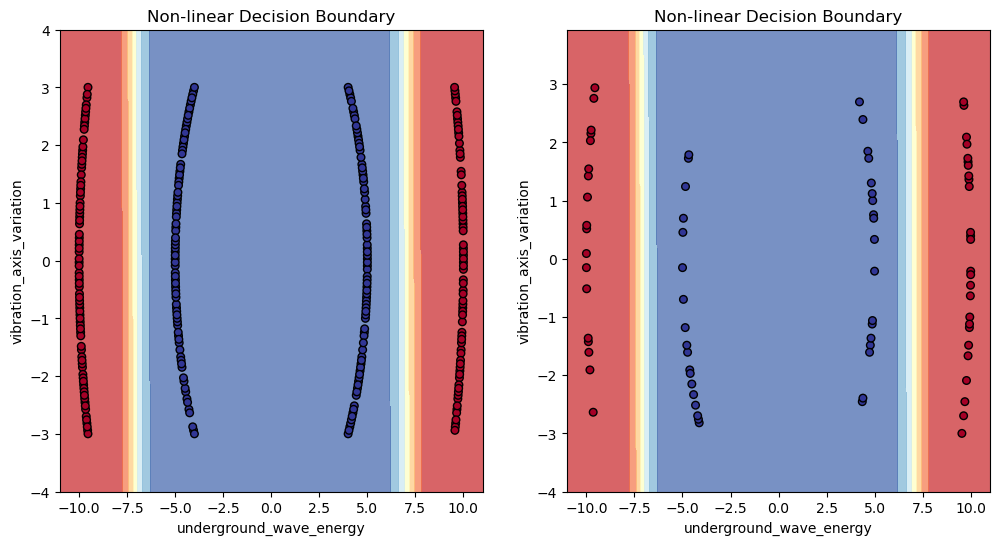

In [21]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()

In [20]:
model.state_dict()

OrderedDict([('first_layer.weight',
              tensor([[-0.6425,  0.0045],
                      [-0.4725, -0.0060],
                      [ 0.5935,  0.0021]])),
             ('first_layer.bias', tensor([-1.3462, -2.2566, -1.8616])),
             ('second_layer.weight',
              tensor([[ 1.4980,  1.6092, -0.4480],
                      [-0.2932, -0.0062,  1.6364],
                      [ 0.5124, -0.7467,  0.2096]])),
             ('second_layer.bias', tensor([-2.3418, -1.6134,  2.0421])),
             ('third_layer.weight', tensor([[-1.5624, -2.7421,  1.8994]])),
             ('third_layer.bias', tensor([1.2586]))])